In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
np.random.seed(42)

data = pd.DataFrame({
    "CGPA": np.random.uniform(5, 10, 1000),
    "StudyHours": np.random.uniform(1, 10, 1000),
    "Attendance": np.random.uniform(50, 100, 1000),
    "Projects": np.random.randint(0, 6, 1000),
    "AptitudeScore": np.random.uniform(30, 100, 1000)
})

data["Placed"] = (
    (data["CGPA"] + data["StudyHours"] +
     data["Attendance"]/10 + data["Projects"] +
     data["AptitudeScore"]/10) > 25
).astype(int)

print(data.head(10))
print(data.shape)
print(data["Placed"].value_counts())

       CGPA  StudyHours  Attendance  Projects  AptitudeScore  Placed
0  6.872701    2.666196   63.085284         2      86.101204       1
1  9.753572    5.877109   62.348940         0      57.446550       1
2  8.659970    8.856513   95.312729         4      82.553875       1
3  7.993292    7.590024   62.477310         5      38.784041       1
4  5.780093    8.259050   63.597486         2      84.093999       1
5  5.779973    6.929050   87.969913         1      46.585333       1
6  5.290418    7.230489   72.486992         2      77.417519       1
7  9.330881    8.642761   88.835528         2      69.604709       1
8  8.005575    3.247012   53.268308         1      95.040130       1
9  8.540363    5.404825   74.378560         3      57.112576       1
(1000, 6)
Placed
1    856
0    144
Name: count, dtype: int64


In [3]:
data.to_csv("SVM_Dataset.csv", index=False)

print("Dataset saved successfully")

Dataset saved successfully


In [4]:
print("Shape:", data.shape)

print("\nData Types:")
print(data.dtypes)

print("\nClass Distribution:")
print(data["Placed"].value_counts())

print("\nDescriptive Statistics:")
print(data.describe())

Shape: (1000, 6)

Data Types:
CGPA             float64
StudyHours       float64
Attendance       float64
Projects           int64
AptitudeScore    float64
Placed             int64
dtype: object

Class Distribution:
Placed
1    856
0    144
Name: count, dtype: int64

Descriptive Statistics:
              CGPA   StudyHours   Attendance     Projects  AptitudeScore  \
count  1000.000000  1000.000000  1000.000000  1000.000000    1000.000000   
mean      7.451283     5.563156    75.120286     2.534000      64.737835   
std       1.460687     2.629709    14.533710     1.726217      20.027495   
min       5.023160     1.028964    50.000582     0.000000      30.002150   
25%       6.179866     3.169668    63.067549     1.000000      47.576771   
50%       7.484037     5.668605    75.030696     3.000000      65.073405   
75%       8.721598     7.844186    87.955176     4.000000      81.428138   
max       9.998588     9.994724    99.891043     5.000000      99.842457   

            Placed  
cou

In [5]:
print("Missing Values:")
print(data.isnull().sum())

print("\nDuplicate Rows:")
print(data.duplicated().sum())

Missing Values:
CGPA             0
StudyHours       0
Attendance       0
Projects         0
AptitudeScore    0
Placed           0
dtype: int64

Duplicate Rows:
0


In [6]:
X = data.drop("Placed", axis=1)
y = data["Placed"]

print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
       CGPA  StudyHours  Attendance  Projects  AptitudeScore
0  6.872701    2.666196   63.085284         2      86.101204
1  9.753572    5.877109   62.348940         0      57.446550
2  8.659970    8.856513   95.312729         4      82.553875
3  7.993292    7.590024   62.477310         5      38.784041
4  5.780093    8.259050   63.597486         2      84.093999

y:
0    1
1    1
2    1
3    1
4    1
Name: Placed, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 5)
Testing data: (200, 5)


In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

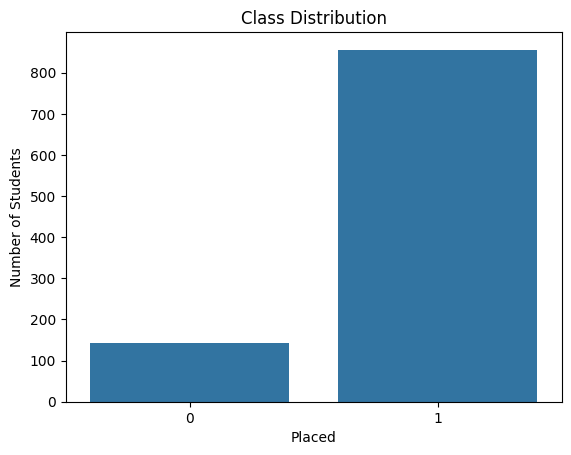

In [9]:
sns.countplot(x="Placed", data=data)

plt.title("Class Distribution")
plt.xlabel("Placed")
plt.ylabel("Number of Students")
plt.show()

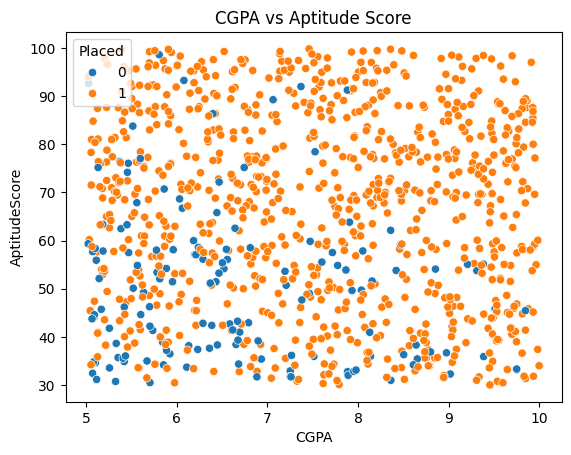

In [10]:
sns.scatterplot(
    x="CGPA",
    y="AptitudeScore",
    hue="Placed",
    data=data
)

plt.title("CGPA vs Aptitude Score")
plt.show()

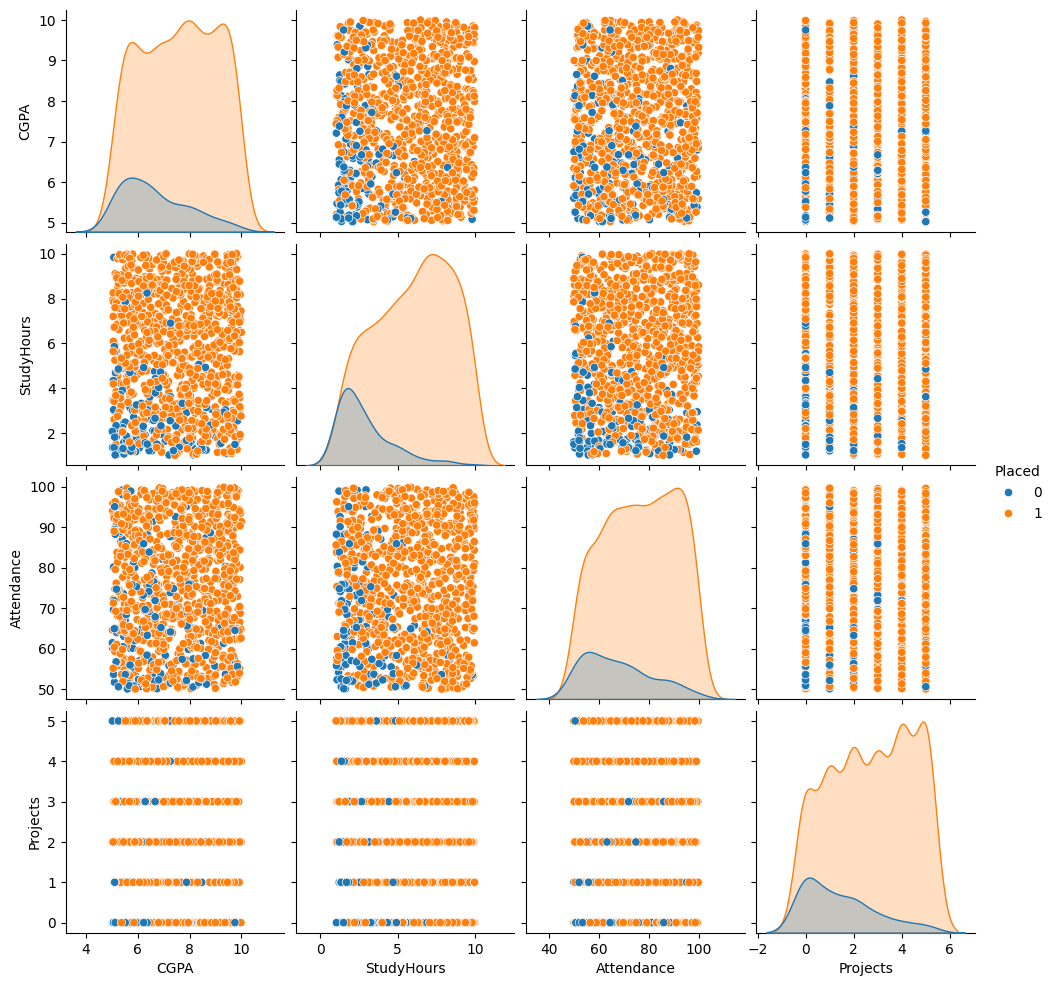

In [11]:
sns.pairplot(
    data[["CGPA", "StudyHours", "Attendance", "Projects", "Placed"]],
    hue="Placed"
)

plt.show()

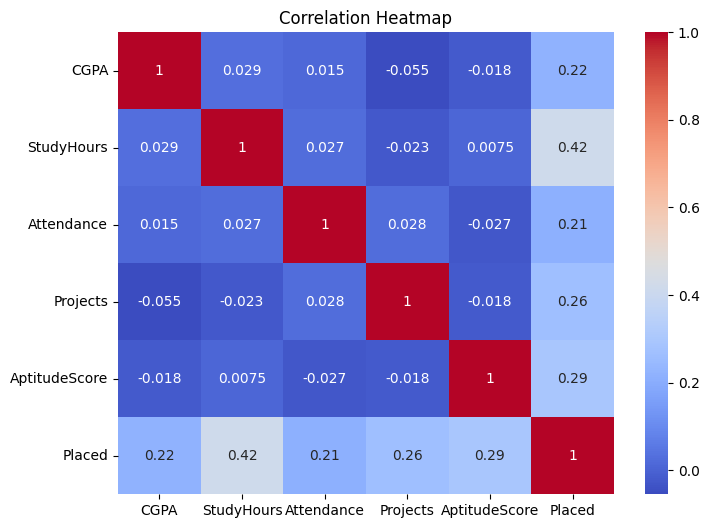

In [12]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [13]:
model = SVC(kernel="linear", C=1)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.97
Precision: 0.9661016949152542
Recall: 1.0
F1 Score: 0.9827586206896551


Confusion Matrix:
[[ 23   6]
 [  0 171]]


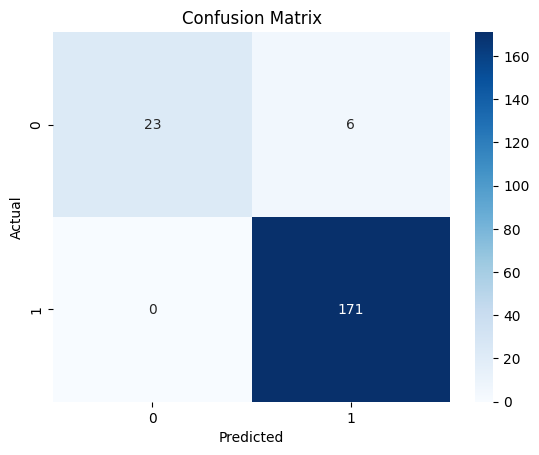

In [15]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
X_2 = data[["CGPA", "AptitudeScore"]]
y_2 = data["Placed"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2, y_2, test_size=0.2, random_state=42
)

scaler2 = StandardScaler()

X2_train = scaler2.fit_transform(X2_train)
X2_test = scaler2.transform(X2_test)

model2 = SVC(kernel="linear", C=1)

model2.fit(X2_train, y2_train)

SVC(C=1, kernel='linear')

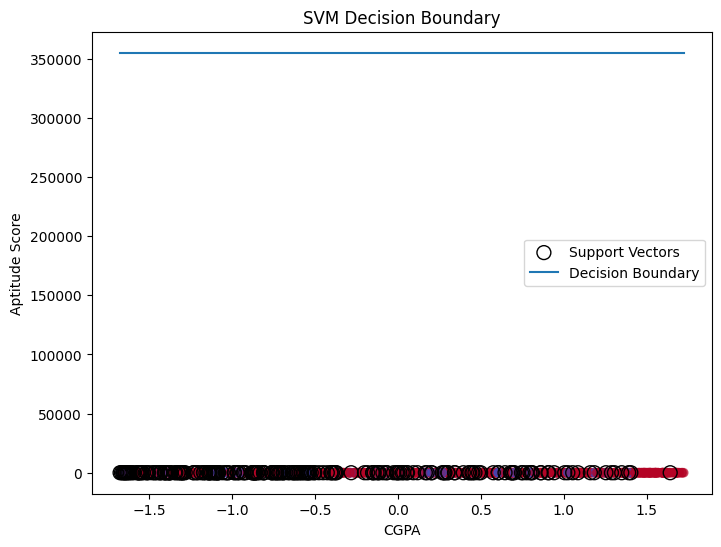

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X2_train[:, 0],
    X2_train[:, 1],
    c=y2_train,
    cmap="coolwarm",
    alpha=0.6
)

plt.scatter(
    model2.support_vectors_[:, 0],
    model2.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)

w = model2.coef_[0]
b = model2.intercept_[0]

x_values = np.linspace(
    X2_train[:, 0].min(),
    X2_train[:, 0].max(),
    100
)

y_values = -(w[0] * x_values + b) / w[1]

plt.plot(
    x_values,
    y_values,
    label="Decision Boundary"
)

plt.xlabel("CGPA")
plt.ylabel("Aptitude Score")
plt.title("SVM Decision Boundary")
plt.legend()
plt.show()

In [18]:
C_values = [0.1, 1, 10]

for c in C_values:

    model = SVC(kernel="linear", C=c)

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    print("C =", c)
    print("Accuracy =", accuracy)
    print()

C = 0.1
Accuracy = 0.955

C = 1
Accuracy = 0.97

C = 10
Accuracy = 0.985



In [19]:
gamma_values = [0.01, 0.1, 1]

for g in gamma_values:

    model = SVC(kernel="rbf", C=1, gamma=g)

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    print("Gamma =", g)
    print("Accuracy =", accuracy)
    print()

Gamma = 0.01
Accuracy = 0.92

Gamma = 0.1
Accuracy = 0.95

Gamma = 1
Accuracy = 0.955



In [20]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.99125
Testing Accuracy: 0.955


In [21]:
model = SVC(kernel="linear", C=1)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [22]:
accuracy_score(y_test, y_pred)
precision_score(y_test, y_pred)
recall_score(y_test, y_pred)
f1_score(y_test, y_pred)
confusion_matrix(y_test, y_pred)

array([[ 23,   6],
       [  0, 171]])